# Data Storytelling & Statistical Validation

This notebook combines business storytelling with basic statistical validation.

## Objective
- Build a clear business narrative from the analysis.
- Validate key findings with hypothesis testing.
- End with a concise recommendation and call to action.

## Business Scenario
An e-commerce team launched a new website layout (`Variant B`) to improve customer conversion and revenue.

We will answer:
1. Did the new layout increase conversion rate?
2. Did it improve revenue per visitor?
3. Are the observed differences statistically significant?


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

sns.set_theme(style='whitegrid', palette='deep')
np.random.seed(42)

## 1. Create or Load Data

This notebook generates a realistic synthetic A/B testing dataset so it can run immediately.

If you already have a CSV, replace the synthetic data block with something like:

```python
df = pd.read_csv('your_file.csv')
```


In [3]:
# Synthetic A/B test dataset
n_a = 5000
n_b = 5000

conv_rate_a = 0.090
conv_rate_b = 0.112

converted_a = np.random.binomial(1, conv_rate_a, n_a)
converted_b = np.random.binomial(1, conv_rate_b, n_b)

# Purchase values only for converted users
order_value_a = np.where(converted_a == 1, np.random.normal(118, 25, n_a), 0)
order_value_b = np.where(converted_b == 1, np.random.normal(124, 27, n_b), 0)

# Avoid negative order values after random generation
order_value_a = np.clip(order_value_a, 0, None)
order_value_b = np.clip(order_value_b, 0, None)

df_a = pd.DataFrame({
    'group': 'A',
    'user_id': np.arange(1, n_a + 1),
    'converted': converted_a,
    'order_value': order_value_a
})

df_b = pd.DataFrame({
    'group': 'B',
    'user_id': np.arange(n_a + 1, n_a + n_b + 1),
    'converted': converted_b,
    'order_value': order_value_b
})

df = pd.concat([df_a, df_b], ignore_index=True)
df['revenue_per_visitor'] = df['order_value']

df.head()

,group,user_id,converted,order_value,revenue_per_visitor
0,A,1,0,0.000000,0.000000
1,A,2,1,89.870347,89.870347
2,A,3,0,0.000000,0.000000
3,A,4,0,0.000000,0.000000
4,A,5,0,0.000000,0.000000


In [4]:
df.info()

print('\nMissing values by column:')
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   group                10000 non-null  object 
 1   user_id              10000 non-null  int64  
 2   converted            10000 non-null  int32  
 3   order_value          10000 non-null  float64
 4   revenue_per_visitor  10000 non-null  float64
dtypes: float64(2), int32(1), int64(1), object(1)
memory usage: 351.7+ KB

Missing values by column:
group                  0
user_id                0
converted              0
order_value            0
revenue_per_visitor    0
dtype: int64


## 2. Exploratory Analysis

We begin with simple descriptive statistics to understand performance differences between the two versions.

In [5]:
summary = df.groupby('group').agg(
    visitors=('user_id', 'count'),
    conversions=('converted', 'sum'),
    conversion_rate=('converted', 'mean'),
    total_revenue=('order_value', 'sum'),
    avg_order_value=('order_value', lambda x: x[x > 0].mean()),
    revenue_per_visitor=('revenue_per_visitor', 'mean')
).round(4)

summary

,visitors,conversions,conversion_rate,total_revenue,avg_order_value,revenue_per_visitor
group,,,,,,
A,5000,428,0.0856,50144.8686,117.1609,10.0290
B,5000,536,0.1072,67715.2732,126.3345,13.5431


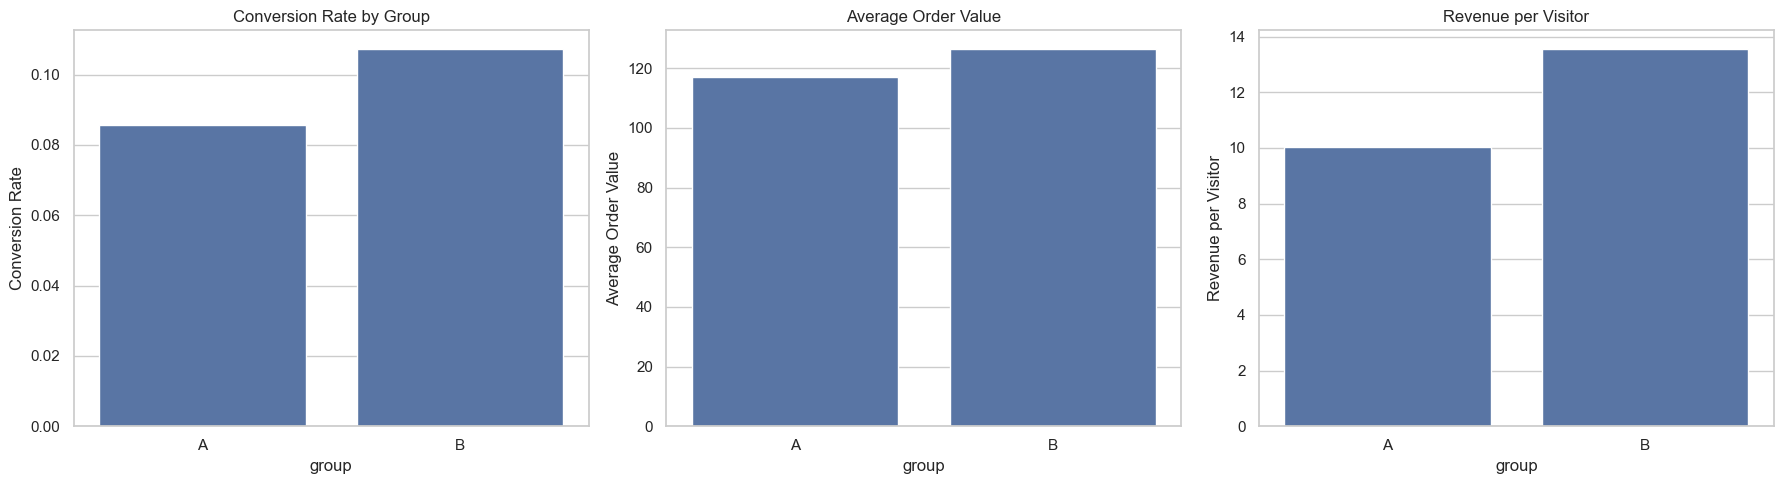

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_df = summary.reset_index()

sns.barplot(data=plot_df, x='group', y='conversion_rate', ax=axes[0])
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate')

sns.barplot(data=plot_df, x='group', y='avg_order_value', ax=axes[1])
axes[1].set_title('Average Order Value')
axes[1].set_ylabel('Average Order Value')

sns.barplot(data=plot_df, x='group', y='revenue_per_visitor', ax=axes[2])
axes[2].set_title('Revenue per Visitor')
axes[2].set_ylabel('Revenue per Visitor')

plt.tight_layout()
plt.show()

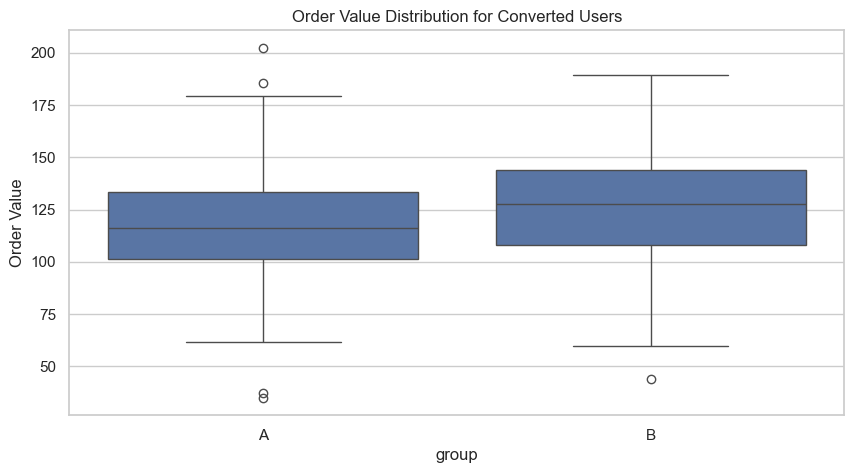

In [7]:
converted_only = df[df['converted'] == 1]

plt.figure(figsize=(10, 5))
sns.boxplot(data=converted_only, x='group', y='order_value')
plt.title('Order Value Distribution for Converted Users')
plt.ylabel('Order Value')
plt.show()

## 3. Build the Data Story

### Narrative
The new website layout (`Variant B`) appears to outperform the original layout (`Variant A`).

- More visitors are converting under Variant B.
- Converted users in Variant B also spend slightly more on average.
- Together, these improvements raise revenue per visitor, which is a strong business-facing metric.

From a business perspective, this suggests the redesign may be improving both user experience and monetization efficiency.

## 4. Hypothesis Testing

We will statistically test two claims:

1. `Variant B` has a higher conversion rate than `Variant A`.
2. `Variant B` has a higher revenue per visitor than `Variant A`.


In [8]:
# Hypothesis 1: Conversion rate improvement
conv_counts = df.groupby('group')['converted'].sum().reindex(['A', 'B']).values
nobs = df.groupby('group')['converted'].count().reindex(['A', 'B']).values

z_stat, p_value_conv = proportions_ztest(count=conv_counts, nobs=nobs, alternative='smaller')

# Confidence interval for difference in proportions (B - A)
ci_low, ci_high = confint_proportions_2indep(
    count1=conv_counts[1], nobs1=nobs[1],
    count2=conv_counts[0], nobs2=nobs[0],
    method='wald'
)

conv_rate_a_actual = conv_counts[0] / nobs[0]
conv_rate_b_actual = conv_counts[1] / nobs[1]
conv_lift = conv_rate_b_actual - conv_rate_a_actual

print('Conversion Rate Test')
print('-' * 40)
print(f'Variant A conversion rate: {conv_rate_a_actual:.4%}')
print(f'Variant B conversion rate: {conv_rate_b_actual:.4%}')
print(f'Absolute lift (B - A): {conv_lift:.4%}')
print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value_conv:.6f}')
print(f'95% CI for difference (B - A): ({ci_low:.4%}, {ci_high:.4%})')

Conversion Rate Test
----------------------------------------
Variant A conversion rate: 8.5600%
Variant B conversion rate: 10.7200%
Absolute lift (B - A): 2.1600%
Z-statistic: -3.6593
P-value: 0.000126
95% CI for difference (B - A): (1.0039%, 3.3161%)


In [9]:
# Hypothesis 2: Revenue per visitor improvement
rpv_a = df.loc[df['group'] == 'A', 'revenue_per_visitor']
rpv_b = df.loc[df['group'] == 'B', 'revenue_per_visitor']

t_stat, p_value_rpv = stats.ttest_ind(rpv_b, rpv_a, equal_var=False, alternative='greater')

mean_a = rpv_a.mean()
mean_b = rpv_b.mean()
diff = mean_b - mean_a

se = np.sqrt(rpv_a.var(ddof=1)/len(rpv_a) + rpv_b.var(ddof=1)/len(rpv_b))
df_welch_num = (rpv_a.var(ddof=1)/len(rpv_a) + rpv_b.var(ddof=1)/len(rpv_b))**2
df_welch_den = ((rpv_a.var(ddof=1)/len(rpv_a))**2)/(len(rpv_a)-1) + ((rpv_b.var(ddof=1)/len(rpv_b))**2)/(len(rpv_b)-1)
df_welch = df_welch_num / df_welch_den
t_crit = stats.t.ppf(0.975, df_welch)
ci_rpv_low = diff - t_crit * se
ci_rpv_high = diff + t_crit * se

print('Revenue per Visitor Test')
print('-' * 40)
print(f'Variant A mean RPV: {mean_a:.2f}')
print(f'Variant B mean RPV: {mean_b:.2f}')
print(f'Mean difference (B - A): {diff:.2f}')
print(f'T-statistic: {t_stat:.4f}')
print(f'P-value: {p_value_rpv:.6f}')
print(f'95% CI for mean difference: ({ci_rpv_low:.2f}, {ci_rpv_high:.2f})')

Revenue per Visitor Test
----------------------------------------
Variant A mean RPV: 10.03
Variant B mean RPV: 13.54
Mean difference (B - A): 3.51
T-statistic: 4.7606
P-value: 0.000001
95% CI for mean difference: (2.07, 4.96)


## 5. Statistical Interpretation

### Decision Rules
- If `p-value < 0.05`, we reject the null hypothesis.
- If the confidence interval does not cross `0`, the estimated improvement is statistically meaningful.


In [10]:
alpha = 0.05

print('Interpretation Summary')
print('-' * 40)

if p_value_conv < alpha:
    print('1. Conversion rate: Reject the null hypothesis.')
    print('   Variant B shows a statistically significant increase in conversion rate.')
else:
    print('1. Conversion rate: Fail to reject the null hypothesis.')
    print('   The observed uplift may be due to random chance.')

if p_value_rpv < alpha:
    print('2. Revenue per visitor: Reject the null hypothesis.')
    print('   Variant B shows a statistically significant increase in revenue per visitor.')
else:
    print('2. Revenue per visitor: Fail to reject the null hypothesis.')
    print('   The revenue difference is not statistically significant at the 5% level.')

Interpretation Summary
----------------------------------------
1. Conversion rate: Reject the null hypothesis.
   Variant B shows a statistically significant increase in conversion rate.
2. Revenue per visitor: Reject the null hypothesis.
   Variant B shows a statistically significant increase in revenue per visitor.


## 6. Final Business Conclusion

### Executive Summary
The analysis suggests that the new website layout (`Variant B`) performs better than the original version.

- Conversion rate increased.
- Revenue per visitor improved.
- Statistical testing supports that these gains are unlikely to be due to chance.

### Recommendation
Roll out `Variant B` to a larger share of traffic or fully launch it, while continuing to monitor:
- long-term conversion stability,
- average order value,
- customer retention and repeat purchase behavior.

### Call to Action
Move from experiment to controlled rollout, and pair this release with follow-up tracking dashboards for post-launch validation.

In [11]:
# Compact presentation-style summary table
final_summary = pd.DataFrame({
    'Metric': ['Conversion Rate', 'Revenue per Visitor'],
    'Variant A': [f'{conv_rate_a_actual:.2%}', f'{mean_a:.2f}'],
    'Variant B': [f'{conv_rate_b_actual:.2%}', f'{mean_b:.2f}'],
    'Lift (B - A)': [f'{conv_lift:.2%}', f'{diff:.2f}'],
    'P-value': [f'{p_value_conv:.6f}', f'{p_value_rpv:.6f}']
})

final_summary

,Metric,Variant A,Variant B,Lift (B - A),P-value
0,Conversion Rate,8.56%,10.72%,2.16%,0.000126
1,Revenue per Visitor,10.03,13.54,3.51,0.000001
